In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt


In [5]:
# Compute covariance matrix for discretization of Brownian motion B_{j/100}, j=1,...,100

C = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        C[i][j]=min(i+1,j+1)/100
C

array([[0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
       [0.01, 0.02, 0.03, ..., 0.03, 0.03, 0.03],
       ...,
       [0.01, 0.02, 0.03, ..., 0.98, 0.98, 0.98],
       [0.01, 0.02, 0.03, ..., 0.98, 0.99, 0.99],
       [0.01, 0.02, 0.03, ..., 0.98, 0.99, 1.  ]])

In [7]:
A = np.linalg.cholesky(C)
Z = np.random.standard_normal((100,5))
X = np.dot(A,Z)
Zero = np.zeros((1,5))
Y = np.vstack([Zero,X])
B = np.transpose(Y)

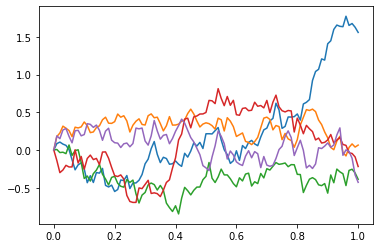

In [8]:
# Plot of 5 sample paths of Brownian motion using Cholesky decomposition

x=np.linspace(0,1,101)
for i in range(5):
    plt.plot(x,B[i])

In [9]:
# Compute covariance matrix for discretization of Brownian bridge U_{j/100}, j=1,...,99

C1 = np.zeros((99,99))
for i in range(99):
    for j in range(99):
        C1[i][j]=min(i+1,j+1)/100-((i+1)/100)*((j+1)/100)
C1

array([[9.90e-03, 9.80e-03, 9.70e-03, ..., 3.00e-04, 2.00e-04, 1.00e-04],
       [9.80e-03, 1.96e-02, 1.94e-02, ..., 6.00e-04, 4.00e-04, 2.00e-04],
       [9.70e-03, 1.94e-02, 2.91e-02, ..., 9.00e-04, 6.00e-04, 3.00e-04],
       ...,
       [3.00e-04, 6.00e-04, 9.00e-04, ..., 2.91e-02, 1.94e-02, 9.70e-03],
       [2.00e-04, 4.00e-04, 6.00e-04, ..., 1.94e-02, 1.96e-02, 9.80e-03],
       [1.00e-04, 2.00e-04, 3.00e-04, ..., 9.70e-03, 9.80e-03, 9.90e-03]])

In [10]:
A1 = np.linalg.cholesky(C1)
Z1 = np.random.standard_normal((99,5))
X1 = np.dot(A1,Z1)
Zero = np.zeros((1,5))
Y1 = np.vstack([Zero,X1,Zero])
U1 = np.transpose(Y1)

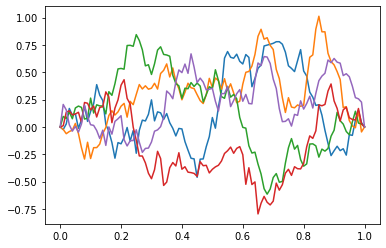

In [12]:
# Plot of 5 sample paths of Brownian bridge using Cholesky decomposition

x=np.linspace(0,1,101)
for i in range(5):
    plt.plot(x,U1[i])

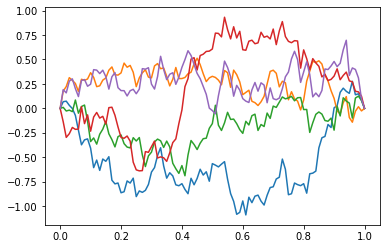

In [13]:
# Plot of 5 sample paths of Brownian bridge using U_t=B_t-tB_1

U2 = np.zeros((5,101))

for i in range(5):
    for j in range(101):
        U2[i][j] = B[i][j] - (j/100) * B[i][100]
x=np.linspace(0,1,101)
for i in range(5):
    plt.plot(x,U2[i])
        

In [14]:
A = np.linalg.cholesky(C)
np.random.seed(0)
Z = np.random.standard_normal((100,5))
X = np.dot(A,Z)
Zero = np.zeros((1,5))
Y = np.vstack([Zero,X])
B = np.transpose(Y)

A1 = np.linalg.cholesky(C1)
np.random.seed(0)
Z1 =  Z[:99]
X1 = np.dot(A1,Z1)
Zero = np.zeros((1,5))
Y1 = np.vstack([Zero,X1,Zero])
U1 = np.transpose(Y1)

for i in range(5):
    for j in range(101):
        U2[i][j] = B[i][j] - (j/100) * B[i][100]

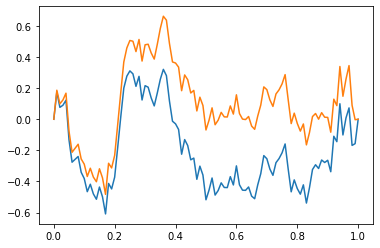

In [15]:
plt.plot(x,U1[0])
plt.plot(x,U2[0])
